# Implementación del Z-Buffer desde Cero
## Gráficos por Computadora — Rasterización y Manejo de Profundidad

Implementa el algoritmo Z-buffer **paso a paso** usando únicamente NumPy y Matplotlib.

### Contenido
1. **Fundamentos**: proyección perspectiva + coordenadas baricéntricas  
2. **Painter's Algorithm**: renderizado sin Z-buffer y sus artefactos  
3. **Z-Buffer**: rasterizador con test de profundidad píxel a píxel  
4. **Visualización del Depth Buffer**: múltiples representaciones  
5. **Comparación**: métricas cuantitativas entre métodos  
6. **Precisión**: near/far planes y simulación de Z-fighting

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#16213e'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'

print(' Librerías cargadas')
print(f'   NumPy  : {np.__version__}')

 Librerías cargadas
   NumPy  : 2.0.2


---
## Módulo 1: Proyección y Coordenadas Baricéntricas

### Proyección Perspectiva
$$x_{screen} = \frac{f \cdot X}{Z} + c_x \qquad y_{screen} = \frac{f \cdot Y}{Z} + c_y$$

### Interpolación de Profundidad (baricéntrica)
$$Z_p = \lambda_0 Z_0 + \lambda_1 Z_1 + \lambda_2 Z_2 \qquad \text{donde } \lambda_0+\lambda_1+\lambda_2=1$$

In [2]:
def project_point(point_3d, focal_length=500, cx=400, cy=300):
    """Proyecta punto 3D (X,Y,Z) al plano de pantalla 2D."""
    X, Y, Z = point_3d
    if Z <= 0:
        return None  # Detrás de la cámara
    px = int(focal_length * X / Z + cx)
    py = int(focal_length * Y / Z + cy)
    return (px, py)

def project_triangle(v0, v1, v2, focal_length=500, cx=400, cy=300):
    """Proyecta los 3 vértices. Retorna pts_2d y profundidades Z."""
    p0 = project_point(v0, focal_length, cx, cy)
    p1 = project_point(v1, focal_length, cx, cy)
    p2 = project_point(v2, focal_length, cx, cy)
    if None in [p0, p1, p2]:
        return None, None
    pts_2d = np.array([p0, p1, p2], dtype=np.float32)
    depths  = np.array([v0[2], v1[2], v2[2]], dtype=np.float32)
    return pts_2d, depths

def barycentric_coords(px, py, v0, v1, v2):
    """
    Coordenadas baricéntricas del punto (px,py) en triángulo (v0,v1,v2).
    Si alguna lambda < 0 → punto fuera del triángulo.
    """
    x0,y0 = v0;  x1,y1 = v1;  x2,y2 = v2
    denom = (y1-y2)*(x0-x2) + (x2-x1)*(y0-y2)
    if abs(denom) < 1e-10:
        return -1, -1, -1   # Triángulo degenerado
    l0 = ((y1-y2)*(px-x2) + (x2-x1)*(py-y2)) / denom
    l1 = ((y2-y0)*(px-x2) + (x0-x2)*(py-y2)) / denom
    l2 = 1.0 - l0 - l1
    return l0, l1, l2

# ─── Tests rápidos ──────────────────────────────────────────────────
p = project_point([0.0, 0.0, 5.0])
print(f' [0,0,5] → {p}  (debe ser el centro de la imagen)')

p2 = project_point([1.0, -0.5, 3.0])
print(f' [1,-0.5,3] → {p2}')

lam = barycentric_coords(1, 1, (0,0), (2,0), (1,2))
print(f'📐 Baricéntricas del centroide: {[round(l,3) for l in lam]}  suma={sum(lam):.4f}')

📍 [0,0,5] → (400, 300)  (debe ser el centro de la imagen)
📍 [1,-0.5,3] → (566, 216)
📐 Baricéntricas del centroide: [0.25, 0.25, 0.5]  suma=1.0000


---
## Módulo 2: Rasterizadores

Dos implementaciones del mismo algoritmo:
- **Sin Z-buffer**: pinta incondicionalmente (Painter's Algorithm)
- **Con Z-buffer**: test `z < zbuffer[y,x]` antes de pintar

In [3]:
def rasterize_no_zbuffer(image, pts_2d, color):
    """
    Rasteriza triángulo SIN test de profundidad.
    Simplemente sobreescribe cualquier color anterior.
    """
    H, W = image.shape[:2]
    v0, v1, v2 = pts_2d
    # Bounding box para no iterar toda la imagen
    min_x = max(0,   int(min(v0[0], v1[0], v2[0])))
    max_x = min(W-1, int(max(v0[0], v1[0], v2[0])))
    min_y = max(0,   int(min(v0[1], v1[1], v2[1])))
    max_y = min(H-1, int(max(v0[1], v1[1], v2[1])))
    count = 0
    for py in range(min_y, max_y + 1):
        for px in range(min_x, max_x + 1):
            l0, l1, l2 = barycentric_coords(px, py, v0, v1, v2)
            if l0 >= 0 and l1 >= 0 and l2 >= 0:
                image[py, px] = color
                count += 1
    return count


def rasterize_zbuffer(image, zbuffer, pts_2d, depths, color):
    """
    Rasteriza triángulo CON Z-buffer.

    Para cada píxel dentro del triángulo:
      1. Calcula Z interpolado con coordenadas baricéntricas
      2. Compara con zbuffer[py, px]
      3. Solo actualiza si Z_nuevo < Z_almacenado (más cercano)
    """
    H, W = image.shape[:2]
    v0, v1, v2 = pts_2d
    z0, z1, z2 = depths
    min_x = max(0,   int(min(v0[0], v1[0], v2[0])))
    max_x = min(W-1, int(max(v0[0], v1[0], v2[0])))
    min_y = max(0,   int(min(v0[1], v1[1], v2[1])))
    max_y = min(H-1, int(max(v0[1], v1[1], v2[1])))
    updated = rejected = 0
    for py in range(min_y, max_y + 1):
        for px in range(min_x, max_x + 1):
            l0, l1, l2 = barycentric_coords(px, py, v0, v1, v2)
            if l0 >= 0 and l1 >= 0 and l2 >= 0:
                #  Interpolación baricéntrica de profundidad
                z_interp = l0*z0 + l1*z1 + l2*z2
                #  TEST Z-BUFFER
                if z_interp < zbuffer[py, px]:
                    zbuffer[py, px] = z_interp   # Actualizar profundidad
                    image[py, px]   = color       # Pintar color
                    updated += 1
                else:
                    rejected += 1                 # Píxel ocluido → descartar
    return updated, rejected

print(' Rasterizadores listos')
print('   rasterize_no_zbuffer() — pintado directo (Painter)')
print('   rasterize_zbuffer()    — con test de profundidad')

 Rasterizadores listos
   rasterize_no_zbuffer() — pintado directo (Painter)
   rasterize_zbuffer()    — con test de profundidad


---
## Módulo 3: Escena 3D de Prueba

Escena diseñada específicamente para revelar artefactos de oclusión:
- Triángulos a distintas profundidades Z
- Un triángulo con **profundidad variable** (magenta) que cruza otros objetos
- Objetos que se solapan en proyección 2D

In [4]:
WIDTH, HEIGHT = 800, 600
FOCAL, CX, CY = 500, 400, 300
BG_COLOR = (20, 20, 35)

scene_triangles = [
    # verts = [(X,Y,Z), ...]  |  color RGB  |  nombre descriptivo
    {'verts': [(-1.2,-0.8,6.0),(1.2,-0.8,6.0),(0.0,1.0,6.0)],
     'color': np.array([220,50,50]),   'name': 'Rojo  (fondo,    Z=6.0)'},
    {'verts': [(-1.0,0.5,4.0),(0.3,0.5,4.0),(-0.4,-0.9,4.0)],
     'color': np.array([50,200,80]),   'name': 'Verde (izquierda,Z=4.0)'},
    {'verts': [(0.2,0.6,4.5),(1.1,-0.4,4.5),(-0.1,-0.7,4.5)],
     'color': np.array([60,100,230]),  'name': 'Azul  (derecha,  Z=4.5)'},
    {'verts': [(-0.3,-0.1,3.0),(0.5,-0.1,3.0),(0.1,0.6,3.0)],
     'color': np.array([240,200,20]),  'name': 'Amarillo (frente,Z=3.0)'},
    {'verts': [(-0.9,-0.2,3.5),(0.9,-0.2,5.5),(0.0,0.9,4.5)],
     'color': np.array([200,50,200]),  'name': 'Magenta (Z var 3.5-5.5)'},
    {'verts': [(-2.0,0.8,7.0),(2.0,0.8,7.0),(0.0,1.8,7.0)],
     'color': np.array([30,180,200]),  'name': 'Cyan   (muy fondo,Z=7.0)'},
]

# Proyectar todos los vértices
projected_scene = []
for tri in scene_triangles:
    v0, v1, v2 = [np.array(v) for v in tri['verts']]
    pts_2d, depths = project_triangle(v0, v1, v2, FOCAL, CX, CY)
    if pts_2d is not None:
        projected_scene.append({
            'pts_2d': pts_2d, 'depths': depths,
            'color': tri['color'],  'name': tri['name'],
            'avg_z': float(np.mean(depths))
        })

print(f' {len(projected_scene)} triángulos proyectados:\n')
print(f'{"Triángulo":<38} {"avg_Z":>8}  {"Vértice A":>14}')
print('─'*65)
for t in projected_scene:
    p = t['pts_2d'][0].astype(int)
    print(f"{t['name']:<38} {t['avg_z']:>8.2f}  ({p[0]:>4},{p[1]:>4})")

 6 triángulos proyectados:

Triángulo                                 avg_Z       Vértice A
─────────────────────────────────────────────────────────────────
Rojo  (fondo,    Z=6.0)                    6.00  ( 300, 233)
Verde (izquierda,Z=4.0)                    4.00  ( 275, 362)
Azul  (derecha,  Z=4.5)                    4.50  ( 422, 366)
Amarillo (frente,Z=3.0)                    3.00  ( 350, 283)
Magenta (Z var 3.5-5.5)                    4.50  ( 271, 271)
Cyan   (muy fondo,Z=7.0)                   7.00  ( 257, 357)


---
## 1️⃣ Renderizado SIN Z-Buffer — Painter's Algorithm

El algoritmo del pintor ordena triángulos por **profundidad media** y los pinta de **atrás hacia adelante**.

⚠️ **Falla cuando**: triángulos se entrecruzan, forman ciclos, o la profundidad media no representa bien la geometría.

⏳ Renderizando Painter's Algorithm...


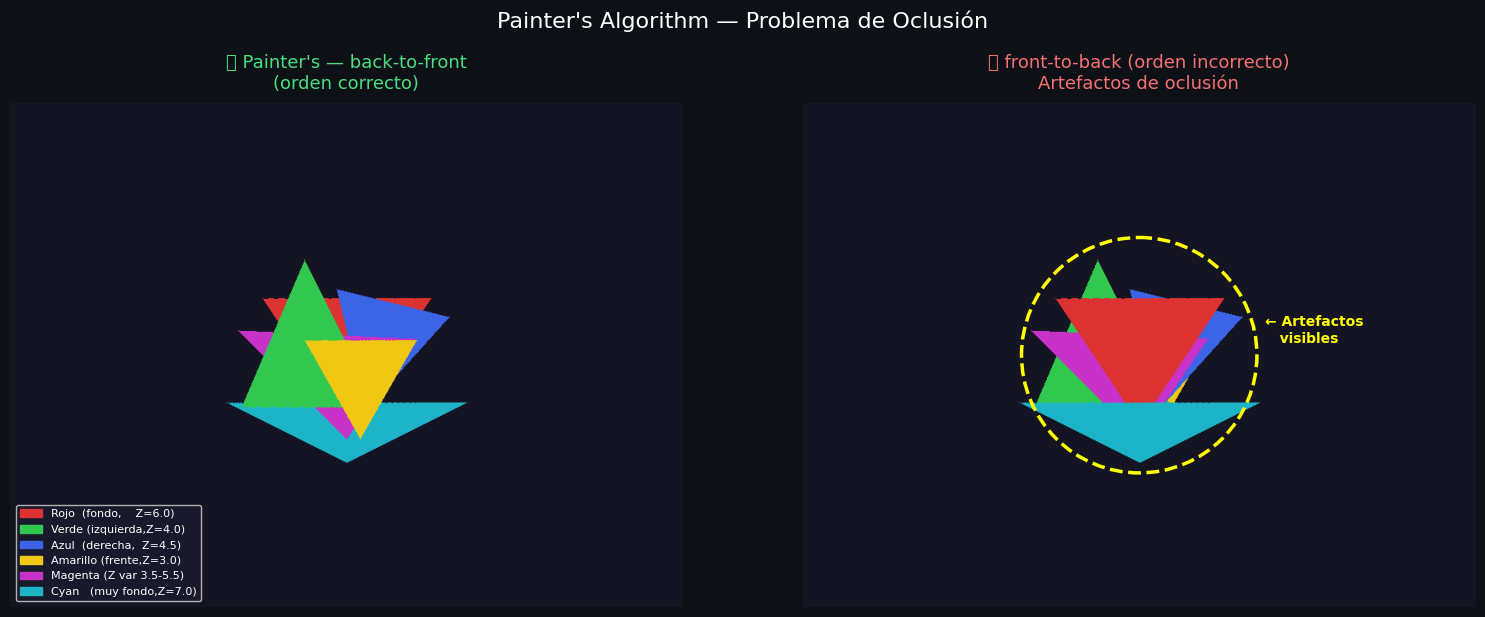

✅ Observa: el orden IMPORTA cuando no hay Z-buffer


In [5]:
def render_painter(tris, front_to_back=False):
    """Renderiza con Painter's Algorithm.
    front_to_back=True  →  orden incorrecto (demuestra artefactos)
    front_to_back=False →  orden correcto (back-to-front)
    """
    img = np.full((HEIGHT, WIDTH, 3), BG_COLOR, dtype=np.uint8)
    sorted_t = sorted(tris, key=lambda t: t['avg_z'], reverse=(not front_to_back))
    for tri in sorted_t:
        rasterize_no_zbuffer(img, tri['pts_2d'], tri['color'])
    return img

print('⏳ Renderizando Painter\'s Algorithm...')
img_painter_correct = render_painter(projected_scene)                 # Correcto
img_painter_wrong   = render_painter(projected_scene, front_to_back=True)  # Incorrecto

legend_elements = [
    mpatches.Patch(color=tuple(t['color']/255), label=t['name'])
    for t in scene_triangles
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

axes[0].imshow(img_painter_correct)
axes[0].set_title("✅ Painter's — back-to-front\n(orden correcto)",
                  fontsize=13, color='#4ade80', pad=10)
axes[0].axis('off')
axes[0].legend(handles=legend_elements, loc='lower left', fontsize=8,
               facecolor='#1a1a2e', labelcolor='white', framealpha=0.85)

axes[1].imshow(img_painter_wrong)
axes[1].set_title("❌ front-to-back (orden incorrecto)\nArtefactos de oclusión",
                  fontsize=13, color='#f87171', pad=10)
axes[1].axis('off')
circle = plt.Circle((CX, CY), 140, color='yellow', fill=False, linewidth=2.5, linestyle='--')
axes[1].add_patch(circle)
axes[1].text(CX+150, CY-15, '← Artefactos\n   visibles', color='yellow', fontsize=10, fontweight='bold')

plt.suptitle("Painter's Algorithm — Problema de Oclusión", fontsize=16, color='white', y=1.02)
plt.tight_layout()
plt.show()
print('✅ Observa: el orden IMPORTA cuando no hay Z-buffer')

---
## 2️⃣ Implementación del Z-Buffer

```
INICIALIZACIÓN:  zbuffer[y,x] = +∞  para todo (x,y)

POR CADA TRIÁNGULO, por cada píxel (px, py):
    λ₀, λ₁, λ₂  = coordenadas_baricéntricas(px, py)
    z_interp     = λ₀·z₀ + λ₁·z₁ + λ₂·z₂

    if z_interp < zbuffer[py, px]:   ← TEST Z
        zbuffer[py, px] = z_interp   ← actualizar
        framebuffer[py, px] = color  ← pintar
    else:
        descartar                     ← ocluido
```

 El orden de pintado ya **no importa** — el Z-buffer garantiza la correctitud.

⏳ Renderizando con Z-buffer...

Estadísticas Z-buffer (orden normal):
Triángulo                               Pintados  Rechazados  Oclusión%
──────────────────────────────────────────────────────────────────────
Rojo  (fondo,    Z=6.0)                   15,111           0       0.0%
Verde (izquierda,Z=4.0)                   14,235           0       0.0%
Azul  (derecha,  Z=4.5)                    8,639         451       5.0%
Amarillo (frente,Z=3.0)                    7,822           0       0.0%
Magenta (Z var 3.5-5.5)                    2,501      10,468      80.7%
Cyan   (muy fondo,Z=7.0)                   7,705       2,533      24.7%

 ¿Mismo resultado en orden invertido? → ✅ SÍ (independencia del orden)


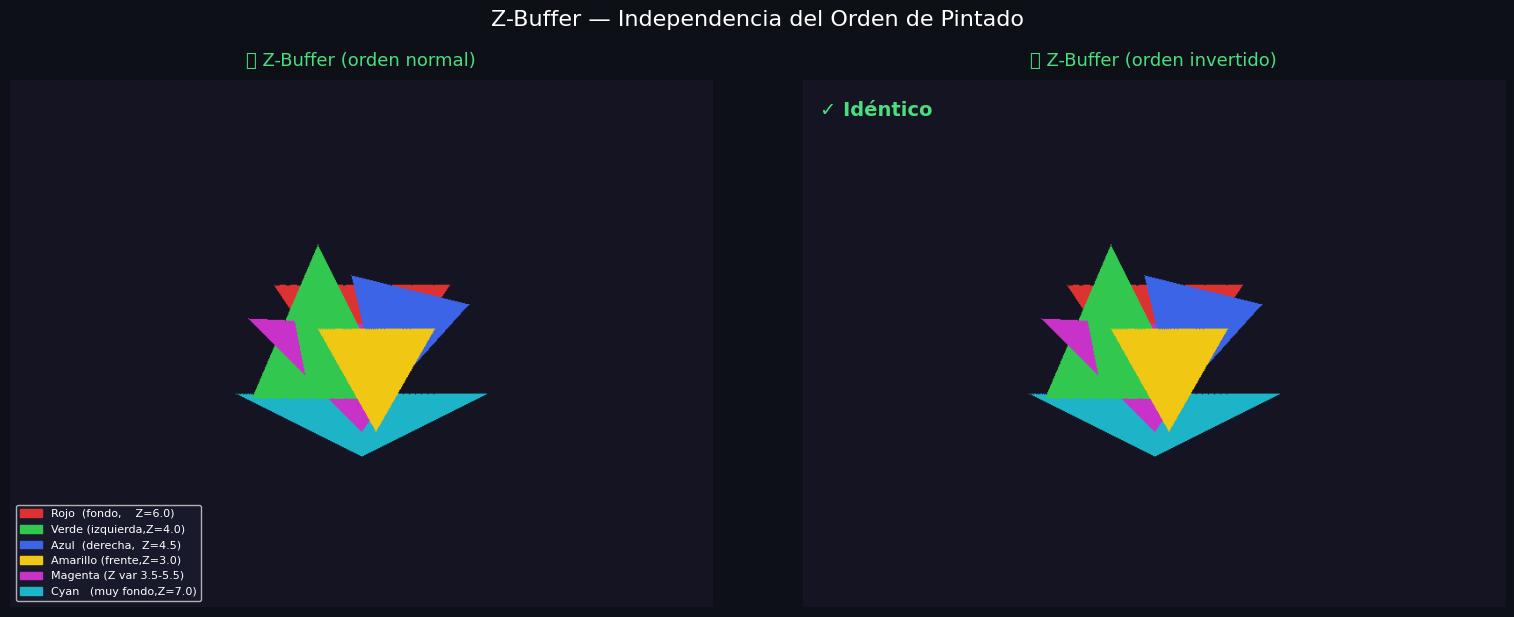

In [6]:
def render_zbuf(tris, reverse_order=False):
    """Renderiza con Z-buffer. reverse_order demuestra independencia del orden."""
    img    = np.full((HEIGHT, WIDTH, 3), BG_COLOR, dtype=np.uint8)
    # ★ INIT: Z-buffer llenado con +infinito ★
    zbuffer = np.full((HEIGHT, WIDTH), np.inf, dtype=np.float32)
    lst = list(reversed(tris)) if reverse_order else tris
    stats = []
    for tri in lst:
        u, r = rasterize_zbuffer(img, zbuffer, tri['pts_2d'], tri['depths'], tri['color'])
        stats.append({'name': tri['name'], 'updated': u, 'rejected': r})
    return img, zbuffer, stats

print('⏳ Renderizando con Z-buffer...')
img_zbuf,     zbuf_data, stats_normal  = render_zbuf(projected_scene)
img_zbuf_rev, _,         _             = render_zbuf(projected_scene, reverse_order=True)
identical = np.array_equal(img_zbuf, img_zbuf_rev)

print('\nEstadísticas Z-buffer (orden normal):')
print(f'{"Triángulo":<38} {"Pintados":>9} {"Rechazados":>11} {"Oclusión%":>10}')
print('─'*70)
for s in stats_normal:
    total = s['updated'] + s['rejected']
    pct   = 100*s['rejected']/total if total else 0
    print(f"{s['name']:<38} {s['updated']:>9,} {s['rejected']:>11,} {pct:>9.1f}%")

print(f'\n ¿Mismo resultado en orden invertido? → {"✅ SÍ" if identical else "❌ NO"} (independencia del orden)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

for ax, img, title in [
    (axes[0], img_zbuf,     '✅ Z-Buffer (orden normal)'),
    (axes[1], img_zbuf_rev, '✅ Z-Buffer (orden invertido)'),
]:
    ax.imshow(img)
    ax.set_title(title, fontsize=13, color='#4ade80', pad=10)
    ax.axis('off')
axes[0].legend(handles=legend_elements, loc='lower left', fontsize=8,
               facecolor='#1a1a2e', labelcolor='white', framealpha=0.85)
axes[1].text(20, 40, f"{'✓ Idéntico' if identical else '✗ Diferente'}",
             color='#4ade80', fontsize=14, fontweight='bold')

plt.suptitle('Z-Buffer — Independencia del Orden de Pintado', fontsize=16, color='white', y=1.02)
plt.tight_layout()
plt.show()

---
## 3️⃣ Visualización del Depth Buffer

El Z-buffer almacena valores de profundidad flotantes. Para visualizarlo:
1. Ignorar píxeles con `+∞` (sin geometría)
2. Normalizar al rango [0, 1]
3. Mapear a escala de colores

 Estadísticas del Depth Buffer:
   Z mínimo  (más cercano)  : 3.0000
   Z máximo  (más lejano)   : 7.0000
   Rango Z                  : 4.0000
   Z medio                  : 4.6097
   Desv. estándar           : 1.4420
   Cobertura de pantalla    : 7.2%
   Memoria del Z-buffer     : 1875 KB (float32)


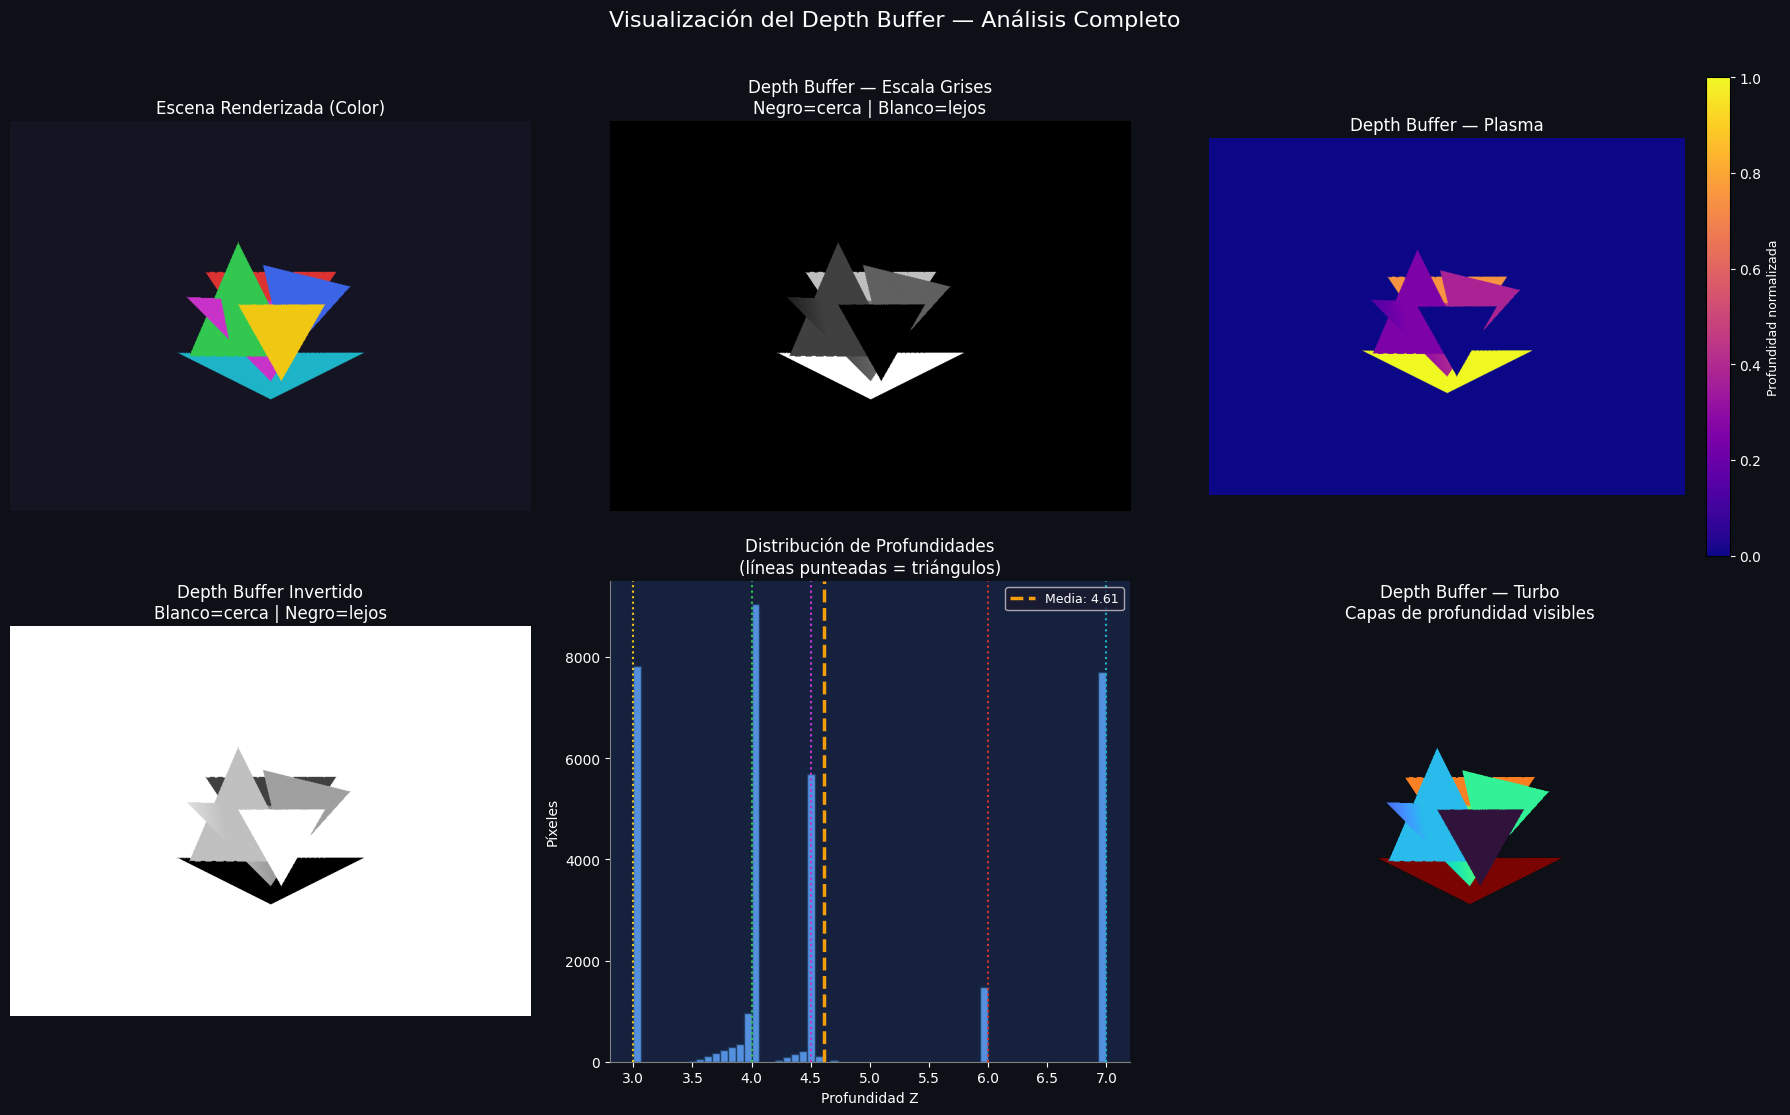

In [7]:
valid_mask = zbuf_data < np.inf
z_min_v = zbuf_data[valid_mask].min()
z_max_v = zbuf_data[valid_mask].max()
z_norm  = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
if (z_max_v - z_min_v) > 0:
    z_norm[valid_mask] = (zbuf_data[valid_mask] - z_min_v) / (z_max_v - z_min_v)
valid_z = zbuf_data[valid_mask]

print(' Estadísticas del Depth Buffer:')
print(f'   Z mínimo  (más cercano)  : {z_min_v:.4f}')
print(f'   Z máximo  (más lejano)   : {z_max_v:.4f}')
print(f'   Rango Z                  : {z_max_v-z_min_v:.4f}')
print(f'   Z medio                  : {valid_z.mean():.4f}')
print(f'   Desv. estándar           : {valid_z.std():.4f}')
print(f'   Cobertura de pantalla    : {100*valid_mask.sum()/(HEIGHT*WIDTH):.1f}%')
print(f'   Memoria del Z-buffer     : {HEIGHT*WIDTH*4/1024:.0f} KB (float32)')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor('#0d1117')

axes[0,0].imshow(img_zbuf)
axes[0,0].set_title('Escena Renderizada (Color)', color='white', fontsize=12); axes[0,0].axis('off')

axes[0,1].imshow(z_norm, cmap='gray', vmin=0, vmax=1)
axes[0,1].set_title('Depth Buffer — Escala Grises\nNegro=cerca | Blanco=lejos', color='white', fontsize=12); axes[0,1].axis('off')

im = axes[0,2].imshow(z_norm, cmap='plasma', vmin=0, vmax=1)
axes[0,2].set_title('Depth Buffer — Plasma', color='white', fontsize=12); axes[0,2].axis('off')
cbar = plt.colorbar(im, ax=axes[0,2], fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors='white'); cbar.set_label('Profundidad normalizada', color='white', fontsize=9)

axes[1,0].imshow(1.0 - z_norm, cmap='gray', vmin=0, vmax=1)
axes[1,0].set_title('Depth Buffer Invertido\nBlanco=cerca | Negro=lejos', color='white', fontsize=12); axes[1,0].axis('off')

axes[1,1].hist(valid_z, bins=60, color='#60a5fa', alpha=0.85, edgecolor='#1e3a5f')
axes[1,1].axvline(valid_z.mean(), color='#f59e0b', linestyle='--', linewidth=2.5,
                  label=f'Media: {valid_z.mean():.2f}')
for tri in scene_triangles:
    avgz = np.mean([v[2] for v in tri['verts']])
    axes[1,1].axvline(avgz, color=tuple(tri['color']/255), linestyle=':', linewidth=1.5)
axes[1,1].set_xlabel('Profundidad Z', color='white'); axes[1,1].set_ylabel('Píxeles', color='white')
axes[1,1].set_title('Distribución de Profundidades\n(líneas punteadas = triángulos)', color='white', fontsize=12)
axes[1,1].legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
axes[1,1].tick_params(colors='white')
for sp in ['top','right']: axes[1,1].spines[sp].set_visible(False)
for sp in ['bottom','left']: axes[1,1].spines[sp].set_color('gray')

axes[1,2].imshow(np.where(zbuf_data<np.inf, z_norm, np.nan), cmap='turbo', vmin=0, vmax=1)
axes[1,2].set_title('Depth Buffer — Turbo\nCapas de profundidad visibles', color='white', fontsize=12); axes[1,2].axis('off')

plt.suptitle('Visualización del Depth Buffer — Análisis Completo', fontsize=16, color='white', y=1.01)
plt.tight_layout()
plt.show()

---
## 4️⃣ Comparación Cuantitativa: Con vs Sin Z-Buffer

📊 Diferencias vs Z-buffer (referencia correcta):
   Painter correcto  : MAE=0.342 |  1,309 píxeles distintos
   Orden incorrecto  : MAE=4.177 | 18,771 píxeles distintos


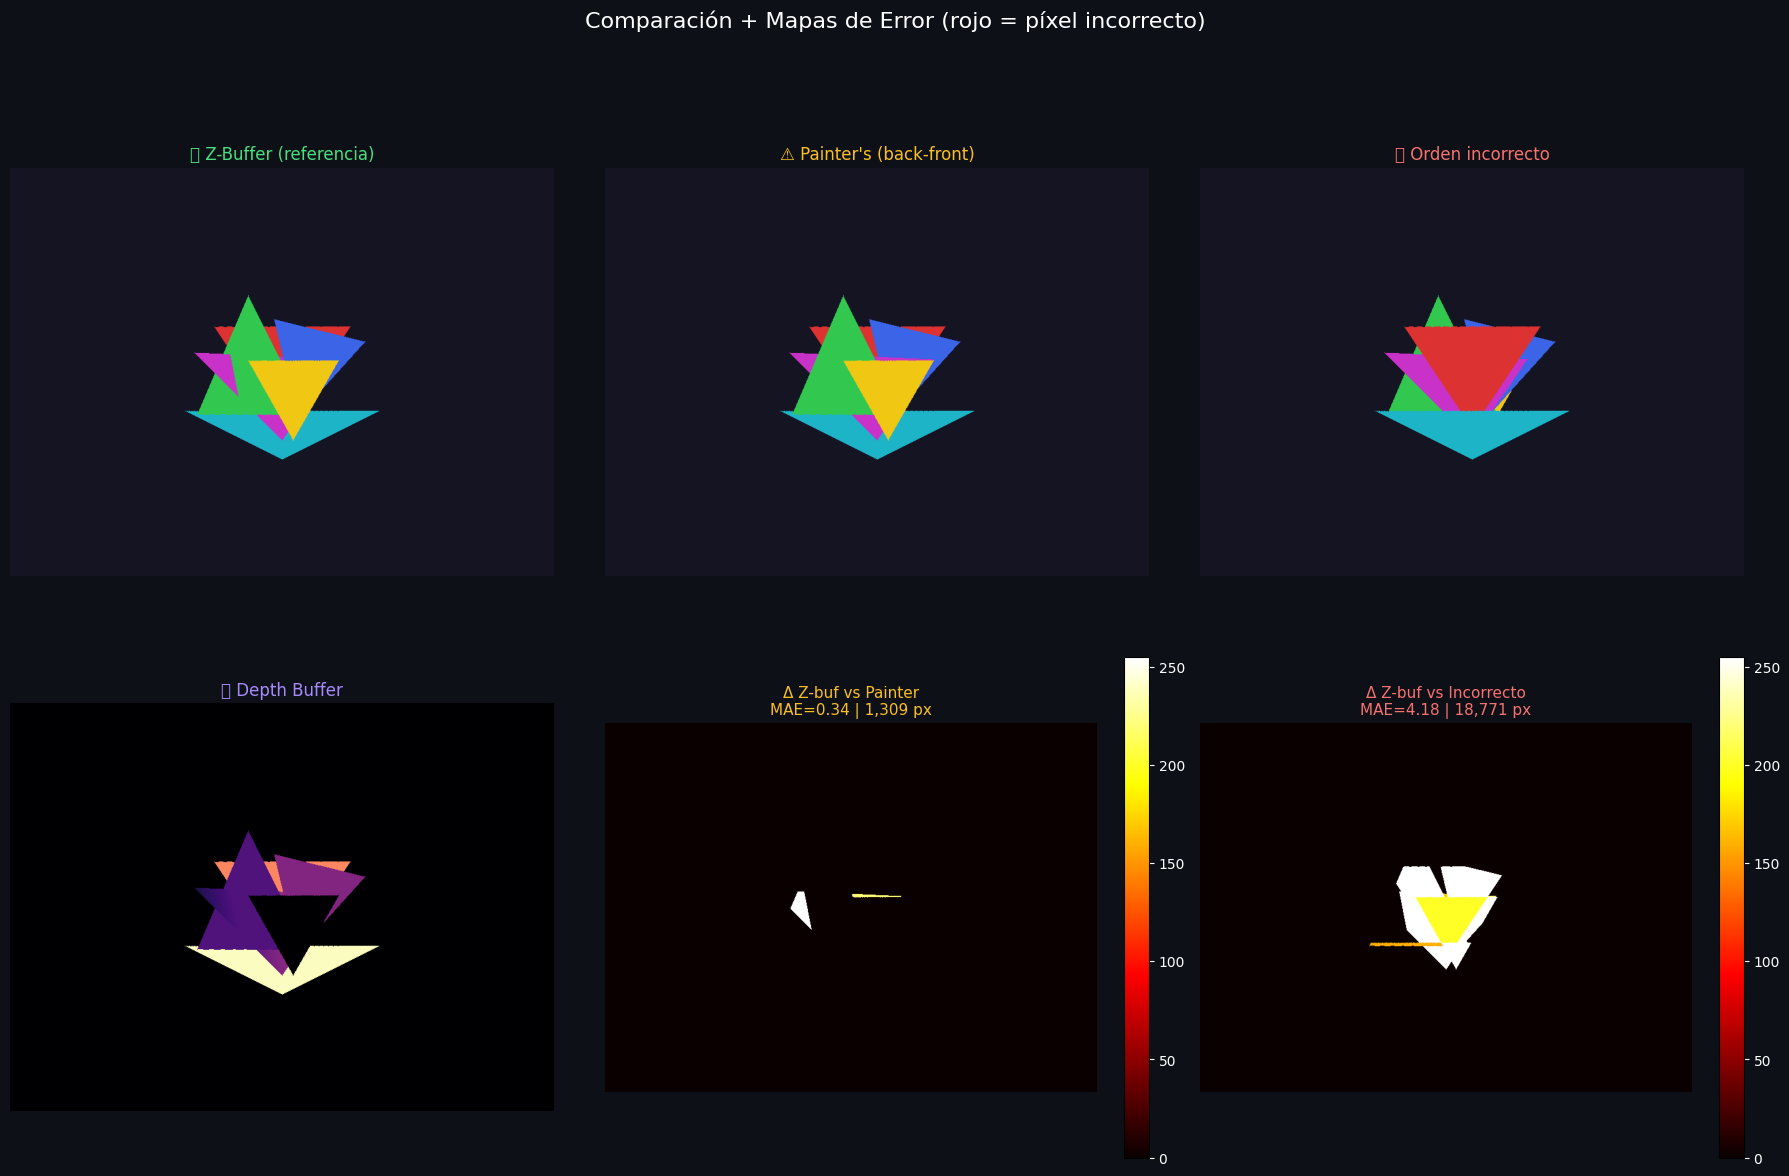

In [8]:
diff_painter = np.abs(img_zbuf.astype(int) - img_painter_correct.astype(int))
diff_wrong   = np.abs(img_zbuf.astype(int) - img_painter_wrong.astype(int))
err_p = (diff_painter.mean(axis=2)*3).clip(0,255).astype(np.uint8)
err_w = (diff_wrong.mean(axis=2)*3).clip(0,255).astype(np.uint8)

mae_p = diff_painter.mean(); px_p = np.sum(err_p > 10)
mae_w = diff_wrong.mean();   px_w = np.sum(err_w > 10)

print('📊 Diferencias vs Z-buffer (referencia correcta):')
print(f'   Painter correcto  : MAE={mae_p:.3f} | {px_p:6,} píxeles distintos')
print(f'   Orden incorrecto  : MAE={mae_w:.3f} | {px_w:6,} píxeles distintos')

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')

for ax, img, ttl, col in [
    (axes[0,0], img_zbuf,            '✅ Z-Buffer (referencia)',   '#4ade80'),
    (axes[0,1], img_painter_correct, "⚠️ Painter's (back-front)",  '#fbbf24'),
    (axes[0,2], img_painter_wrong,   '❌ Orden incorrecto',         '#f87171'),
]:
    ax.imshow(img); ax.set_title(ttl, color=col, fontsize=12); ax.axis('off')

axes[1,0].imshow(z_norm, cmap='magma')
axes[1,0].set_title('🗺️ Depth Buffer', color='#a78bfa', fontsize=12); axes[1,0].axis('off')

im1 = axes[1,1].imshow(err_p, cmap='hot', vmin=0, vmax=255)
axes[1,1].set_title(f'Δ Z-buf vs Painter\nMAE={mae_p:.2f} | {px_p:,} px', color='#fbbf24', fontsize=11)
axes[1,1].axis('off'); plt.colorbar(im1, ax=axes[1,1], fraction=0.046)

im2 = axes[1,2].imshow(err_w, cmap='hot', vmin=0, vmax=255)
axes[1,2].set_title(f'Δ Z-buf vs Incorrecto\nMAE={mae_w:.2f} | {px_w:,} px', color='#f87171', fontsize=11)
axes[1,2].axis('off'); plt.colorbar(im2, ax=axes[1,2], fraction=0.046)

plt.suptitle('Comparación + Mapas de Error (rojo = píxel incorrecto)', fontsize=16, color='white', y=1.01)
plt.tight_layout()
plt.show()

---
## 5️⃣ Experimentación con Precisión

### Problema 1: Distribución No Lineal (Near/Far Planes)
En OpenGL, la transformación a NDC (*Normalized Device Coordinates*) es:
$$z_{NDC} = \frac{far+near}{far-near} - \frac{2 \cdot far \cdot near}{(far-near)\cdot z}$$
Esta es **no lineal**: la mayoría de los bits se concentran cerca de la cámara.

### Problema 2: Z-Fighting
Cuando dos superficies están a casi la misma profundidad, los errores de redondeo float32 hacen que el test Z sea inconsistente píxel a píxel → patrón de ruido visual.

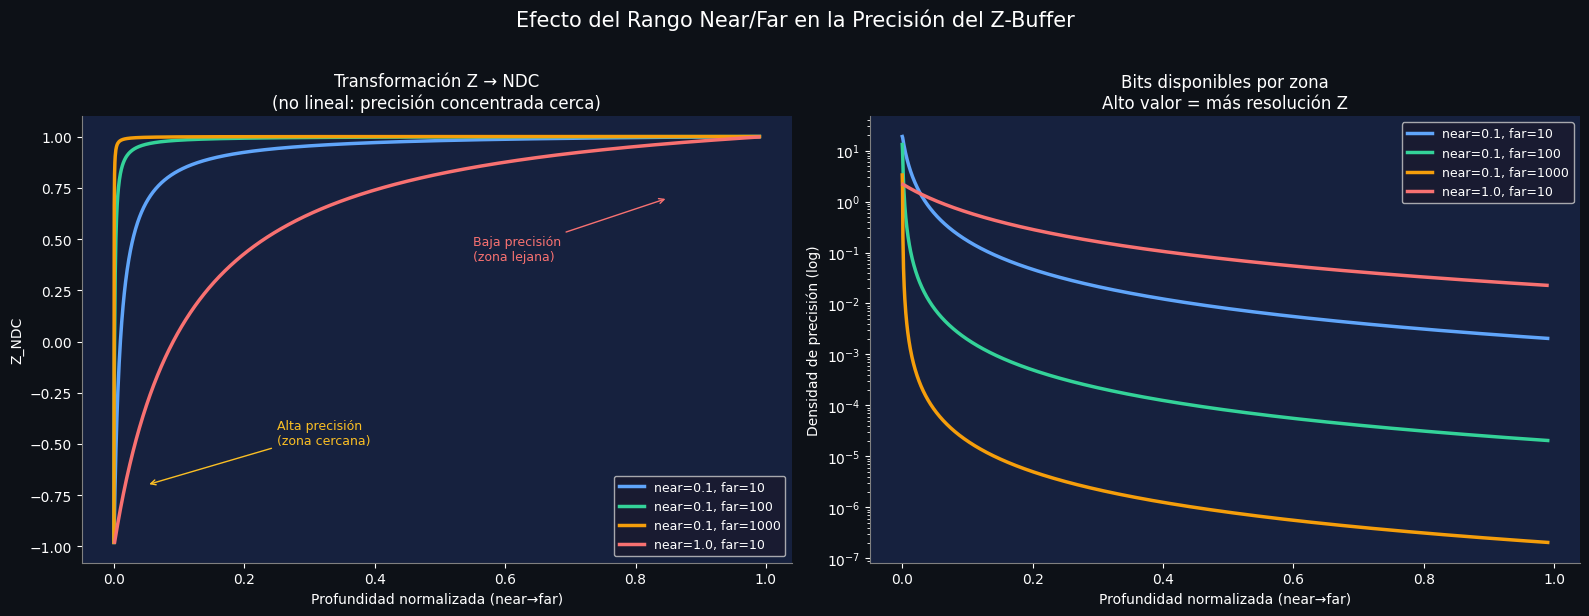

In [9]:
# ─── PARTE A: PRECISIÓN NEAR/FAR ───────────────────────────────
def z_ndc(z, near, far):
    """Transforma Z lineal a NDC no-lineal (como OpenGL)."""
    return (far+near)/(far-near) - (2*far*near)/((far-near)*z)

configs = [
    ('near=0.1, far=10',   0.1,   10,  '#60a5fa'),
    ('near=0.1, far=100',  0.1,  100,  '#34d399'),
    ('near=0.1, far=1000', 0.1, 1000,  '#f59e0b'),
    ('near=1.0, far=10',   1.0,   10,  '#f87171'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

for label, near, far, col in configs:
    z_w  = np.linspace(near*1.01, far*0.99, 2000)
    z_n  = z_ndc(z_w, near, far)
    prec = np.abs(np.gradient(z_n, z_w))
    z_norm_plot = (z_w - near) / (far - near)
    axes[0].plot(z_norm_plot, z_n,   color=col, linewidth=2.5, label=label)
    axes[1].semilogy(z_norm_plot, prec, color=col, linewidth=2.5, label=label)

axes[0].set_xlabel('Profundidad normalizada (near→far)', color='white')
axes[0].set_ylabel('Z_NDC', color='white')
axes[0].set_title('Transformación Z → NDC\n(no lineal: precisión concentrada cerca)',
                  color='white', fontsize=12)
axes[0].annotate('Alta precisión\n(zona cercana)', xy=(0.05,-0.7), xytext=(0.25,-0.5),
    color='#fbbf24', fontsize=9, arrowprops=dict(arrowstyle='->', color='#fbbf24'))
axes[0].annotate('Baja precisión\n(zona lejana)',  xy=(0.85, 0.7), xytext=(0.55, 0.4),
    color='#f87171', fontsize=9, arrowprops=dict(arrowstyle='->', color='#f87171'))

axes[1].set_xlabel('Profundidad normalizada (near→far)', color='white')
axes[1].set_ylabel('Densidad de precisión (log)', color='white')
axes[1].set_title('Bits disponibles por zona\nAlto valor = más resolución Z',
                  color='white', fontsize=12)

for ax in axes:
    ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
    ax.tick_params(colors='white')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('gray')

plt.suptitle('Efecto del Rango Near/Far en la Precisión del Z-Buffer', fontsize=15, color='white', y=1.02)
plt.tight_layout()
plt.show()

Z-Fighting: análisis por separación ΔZ
        ΔZ  Resultado                  Recomendación
─────────────────────────────────────────────────────────────────
    0.5000  ✅ Sin artefactos           OK
    0.0500  ⚠️  Limítrofe              Usar float64
    0.0050  ❌ Z-fighting leve          Alejár objetos
    0.0001  🔥 Z-fighting severo        Rediseñar escena


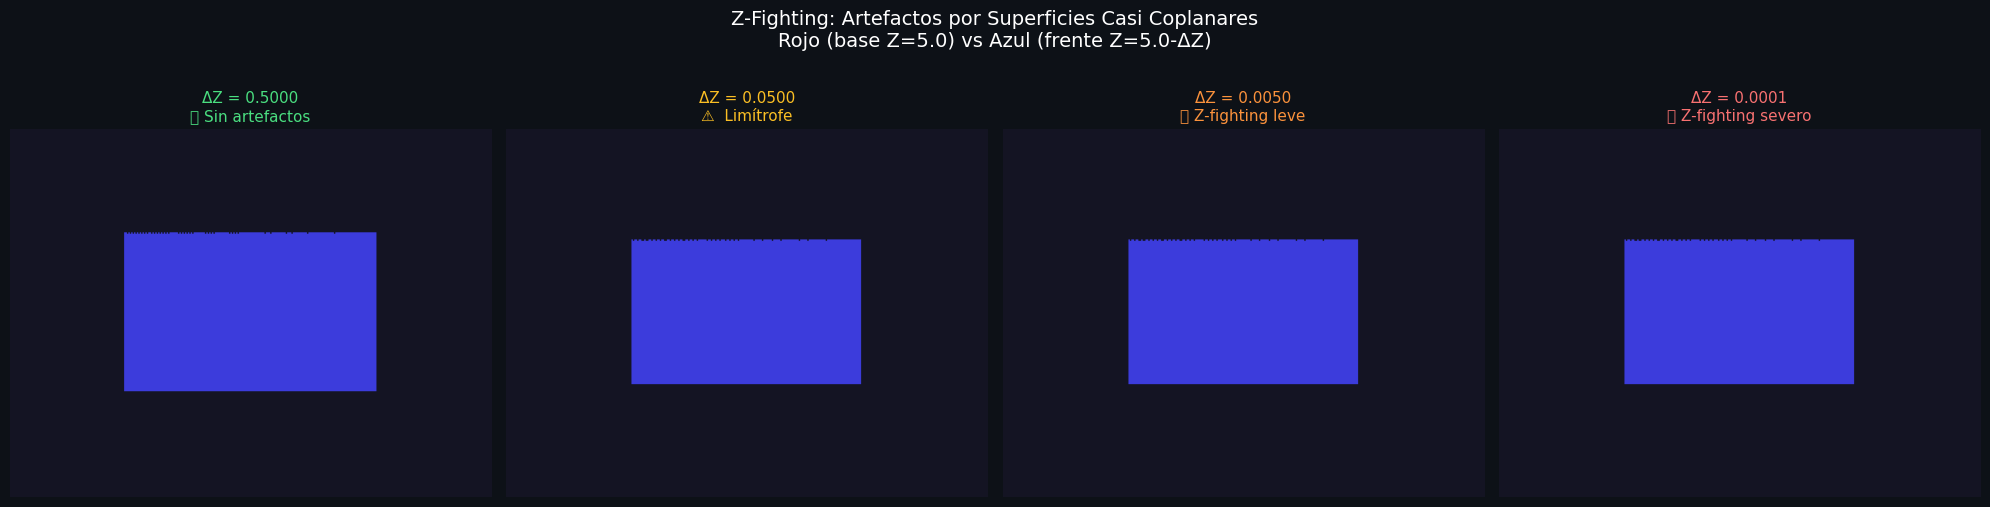

In [10]:
# ─── PARTE B: Z-FIGHTING ────────────────────────────────────────
def make_zfight_scene(sep):
    """Dos cuadrados (4 triángulos) con separación ΔZ = sep."""
    z_base  = 5.0
    z_front = z_base - sep
    raw = [
        {'verts': [(-0.8,-0.5,z_base), ( 0.8,-0.5,z_base), ( 0.8, 0.5,z_base)], 'color': np.array([220,60,60])},
        {'verts': [(-0.8,-0.5,z_base), ( 0.8, 0.5,z_base), (-0.8, 0.5,z_base)], 'color': np.array([220,60,60])},
        {'verts': [(-0.8,-0.5,z_front),( 0.8,-0.5,z_front),( 0.8, 0.5,z_front)],'color': np.array([60,60,220])},
        {'verts': [(-0.8,-0.5,z_front),( 0.8, 0.5,z_front),(-0.8, 0.5,z_front)],'color': np.array([60,60,220])},
    ]
    scene = []
    for tri in raw:
        v0,v1,v2 = [np.array(v) for v in tri['verts']]
        pts_2d, depths = project_triangle(v0,v1,v2,FOCAL,CX,CY)
        if pts_2d is not None:
            scene.append({'pts_2d':pts_2d,'depths':depths,'color':tri['color'],'avg_z':np.mean(depths),'name':''})
    return scene

separations = [0.5, 0.05, 0.005, 0.0001]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#0d1117')

print('Z-Fighting: análisis por separación ΔZ')
print(f'{"ΔZ":>10}  {"Resultado":<25}  {"Recomendación"}')
print('─'*65)

for ax, sep in zip(axes, separations):
    scene_zf = make_zfight_scene(sep)
    img_zf   = np.full((HEIGHT,WIDTH,3), BG_COLOR, dtype=np.uint8)
    zbuf_zf  = np.full((HEIGHT,WIDTH), np.inf, dtype=np.float32)
    for tri in scene_zf:
        rasterize_zbuffer(img_zf, zbuf_zf, tri['pts_2d'], tri['depths'], tri['color'])

    ax.imshow(img_zf)
    ax.set_xlim(CX-170, CX+170); ax.set_ylim(CY+130, CY-130)

    if   sep >= 0.1:    status='✅ Sin artefactos';   col='#4ade80'; rec='OK'
    elif sep >= 0.01:   status='⚠️  Limítrofe';         col='#fbbf24'; rec='Usar float64'
    elif sep >= 0.001:  status='❌ Z-fighting leve';   col='#fb923c'; rec='Alejár objetos'
    else:               status='🔥 Z-fighting severo'; col='#f87171'; rec='Rediseñar escena'

    ax.set_title(f'ΔZ = {sep:.4f}\n{status}', color=col, fontsize=11)
    ax.axis('off')
    print(f'{sep:>10.4f}  {status:<25}  {rec}')

plt.suptitle('Z-Fighting: Artefactos por Superficies Casi Coplanares\nRojo (base Z=5.0) vs Azul (frente Z=5.0-ΔZ)',
             fontsize=14, color='white', y=1.05)
plt.tight_layout()
plt.show()

---
## 📋 Resumen y Conclusiones

| Método | Corrección | Memoria | Orden necesario |
|--------|-----------|---------|----------------|
| Painter's (back-to-front) | ✅ Solo objetos convexos separados | O(1) | Sí (sort) |
| Painter's (general) | ❌ Falla con triángulos entrelazados | O(1) | Sí |
| **Z-buffer** | **✅ Siempre correcto** | **O(W×H)** | **No** |

### ✅ Ventajas del Z-buffer
- **Orden independiente**: no requiere sort O(n log n)
- **Triángulos entrelazados**: maneja geometría compleja
- **Hardware friendly**: paralelizable por GPU (millones de píxeles en paralelo)

### ⚠️ Limitaciones
- **Z-fighting**: ΔZ < resolución float32 → ruido visual
- **Precisión no lineal**: mejor resolución cerca, peor lejos
- **Memoria**: 800×600×4 bytes ≈ 1.8 MB solo para depth buffer
- **Transparencia**: requiere técnicas adicionales (OIT)